# task 1
## pneumonia MRI classification

using supervised leanring we train 3 models to find pneumonia in chest MRI imagery, compare 3 models on the same pneumonia dataset and explain which one is best

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from medmnist import PneumoniaMNIST, BloodMNIST

MAX_LEN = 3000
np.random.seed(42)


## dataset: pneumoniamnist from medmnist

you - medmnist is a py lib with 122k medical images for model training, here we are using the pneumonia dataset with dual classification so either normal (healthy) or pneumonia
- the images are grayscale 28x28 chest xray images, easier than the chestmnist 3 class problem so higher scores are expected here

In [2]:
train_dataset = PneumoniaMNIST(split='train', download=True)
val_dataset = PneumoniaMNIST(split='val')
test_dataset = PneumoniaMNIST(split='test')

X = np.concatenate([
    train_dataset.imgs,
    val_dataset.imgs,
    test_dataset.imgs,
])

y = np.concatenate([
    train_dataset.labels,
    val_dataset.labels,
    test_dataset.labels,
]).flatten()

indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

X = X[:MAX_LEN]
y = y[:MAX_LEN]

label_names = [test_dataset.info['label'][str(i)] for i in range(len(test_dataset.info['label']))]
class_names = [str(name) for name in label_names]

X_images = X.copy()
X_flat = X.reshape(X.shape[0], -1).astype(float)
X_flat = X_flat / 255.0

print('label names:', class_names)
unique, counts = np.unique(y, return_counts=True)
print('labels:', unique)
print('counts:', counts)
print('percentage:', counts / len(y) * 100)
print('dataset size after truncation:', len(y))
print('flattened feature shape:', X_flat.shape)


label names: ['normal', 'pneumonia']
labels: [0 1]
counts: [ 839 2161]
percentage: [27.96666667 72.03333333]
dataset size after truncation: 3000
flattened feature shape: (3000, 784)


## data quality and preprocessing

- all images are flattened from 28x28 to 784 features
- pixel values are normalized to [0, 1] (black & white)
- same preprocessing is used for every model so the comparison stays fair

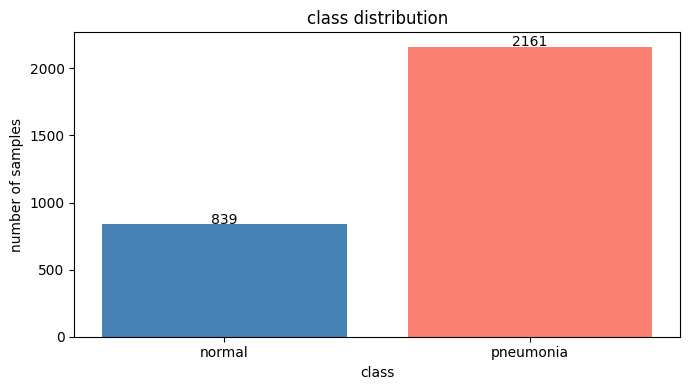

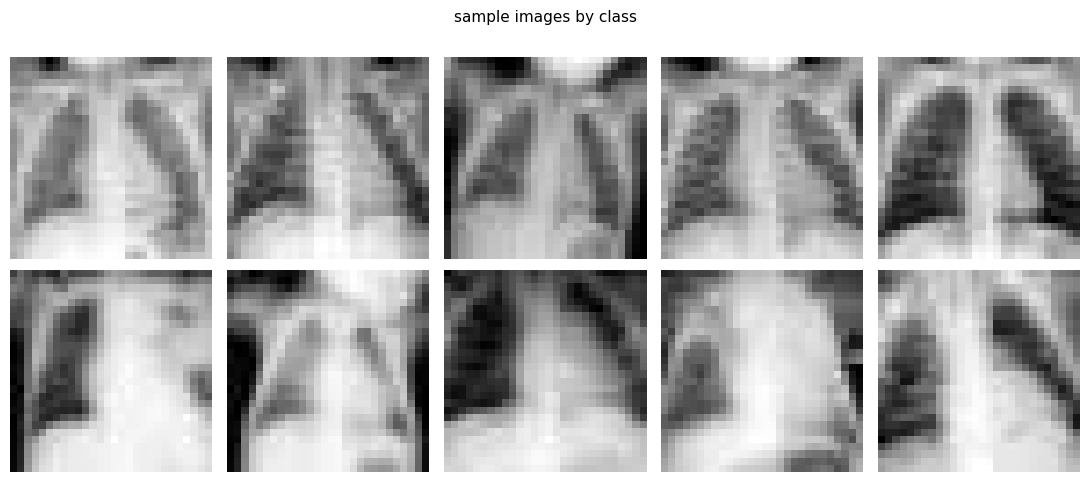

In [3]:
unique, counts = np.unique(y, return_counts=True)
name_map = {0: class_names[0], 1: class_names[1]}
plot_names = [name_map[int(v)] for v in unique]

plt.figure(figsize=(7, 4))
bars = plt.bar(plot_names, counts, color=['steelblue', 'salmon'])
plt.title('class distribution')
plt.xlabel('class')
plt.ylabel('number of samples')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(int(count)), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for row, class_value in enumerate(unique):
    class_indices = np.where(y == class_value)[0][:5]
    for col, idx in enumerate(class_indices):
        axes[row, col].imshow(X_images[idx], cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name_map[int(class_value)], rotation=20, labelpad=28)
fig.suptitle('sample images by class', fontsize=11)
plt.tight_layout()
plt.show()


## experimental protocol

- same dataset, same split, same flattened features for all 3 pneumonia models
- metrics: accuracy, precision, recall, f1, train time, inference time
- model 1/2/3 are directly comparable because they use the exact same binary dataset
- extra model 4 is a separate multi-class medical task (different dataset), shown as additional work


In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=42,
)

print(f'train: {len(x_train)} | test: {len(x_test)}')
results = {}


train: 2400 | test: 600


## model 1 : svc

- this is the model that already worked best in this notebook before
- it tries many `C` and `gamma` values, then keeps the best combination
- good fit for this binary task with flattened data
- main downside: slowest model here because gridsearch tests multiple combinations


best params: {'C': 5, 'gamma': 0.05}
accuracy:  0.9700
precision: 0.9683
recall:    0.9907
f1:        0.9794
train time: 23.00s | inference time: 0.0992s

               precision    recall  f1-score   support

      normal       0.97      0.92      0.94       168
   pneumonia       0.97      0.99      0.98       432

    accuracy                           0.97       600
   macro avg       0.97      0.95      0.96       600
weighted avg       0.97      0.97      0.97       600



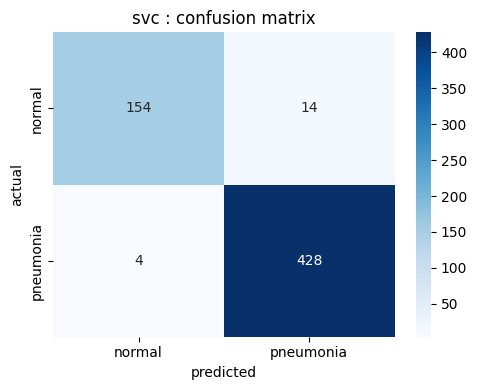

In [5]:
classifier = SVC()
parameters = [{'gamma': [0.1, 0.07, 0.05], 'C': [1, 5, 10, 15, 20]}]

t0 = time.time()
grid_search = GridSearchCV(classifier, parameters, cv=3, n_jobs=-1)
grid_search.fit(x_train, y_train)
svc_train_time = time.time() - t0

best_estimator = grid_search.best_estimator_

t0 = time.time()
y_pred_svc = best_estimator.predict(x_test)
svc_infer_time = time.time() - t0

acc = accuracy_score(y_test, y_pred_svc)
prec = precision_score(y_test, y_pred_svc, zero_division=0)
rec = recall_score(y_test, y_pred_svc, zero_division=0)
f1 = f1_score(y_test, y_pred_svc, zero_division=0)

results['SVC'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'train_time': svc_train_time,
    'infer_time': svc_infer_time,
}

print(f'best params: {grid_search.best_params_}')
print(f'accuracy:  {acc:.4f}')
print(f'precision: {prec:.4f}')
print(f'recall:    {rec:.4f}')
print(f'f1:        {f1:.4f}')
print(f'train time: {svc_train_time:.2f}s | inference time: {svc_infer_time:.4f}s')
print('\n', classification_report(y_test, y_pred_svc, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_svc, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('svc : confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.tight_layout()
plt.show()


## model 2 : random forest

- second supervised model for comparison
- much faster to train than svc
- each tree makes simple split decisions, then the forest votes
- useful baseline because it is a very different model family from svc


accuracy:  0.9467
precision: 0.9425
recall:    0.9861
f1:        0.9638
train time: 0.44s | inference time: 0.0236s

               precision    recall  f1-score   support

      normal       0.96      0.85      0.90       168
   pneumonia       0.94      0.99      0.96       432

    accuracy                           0.95       600
   macro avg       0.95      0.92      0.93       600
weighted avg       0.95      0.95      0.95       600



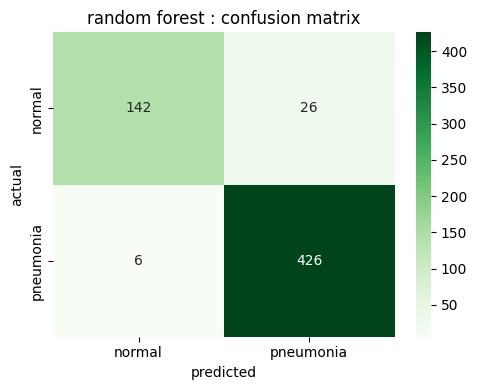

In [6]:
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
rf_train_time = time.time() - t0

t0 = time.time()
y_pred_rf = rf.predict(x_test)
rf_infer_time = time.time() - t0

acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf, zero_division=0)
rec = recall_score(y_test, y_pred_rf, zero_division=0)
f1 = f1_score(y_test, y_pred_rf, zero_division=0)

results['RandomForest'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'train_time': rf_train_time,
    'infer_time': rf_infer_time,
}

print(f'accuracy:  {acc:.4f}')
print(f'precision: {prec:.4f}')
print(f'recall:    {rec:.4f}')
print(f'f1:        {f1:.4f}')
print(f'train time: {rf_train_time:.2f}s | inference time: {rf_infer_time:.4f}s')
print('\n', classification_report(y_test, y_pred_rf, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('random forest : confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.tight_layout()
plt.show()


## model 3 : logistic regression

- third comparable supervised model on the same pneumonia dataset
- fast linear baseline for binary classification
- optimized with log loss (cross entropy)
- usually slightly weaker than svc, but often very fast and stable


accuracy:  0.9600
precision: 0.9595
recall:    0.9861
f1:        0.9726
train time: 10.14s | inference time: 0.0380s

               precision    recall  f1-score   support

      normal       0.96      0.89      0.93       168
   pneumonia       0.96      0.99      0.97       432

    accuracy                           0.96       600
   macro avg       0.96      0.94      0.95       600
weighted avg       0.96      0.96      0.96       600



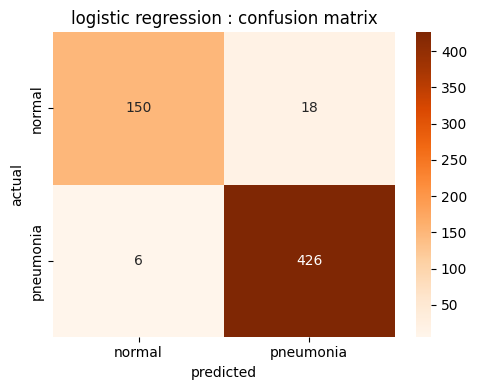

In [7]:
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train, y_train)
lr_train_time = time.time() - t0

t0 = time.time()
y_pred_lr = lr.predict(x_test)
lr_infer_time = time.time() - t0

acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr, zero_division=0)
rec = recall_score(y_test, y_pred_lr, zero_division=0)
f1 = f1_score(y_test, y_pred_lr, zero_division=0)

results['LogReg'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'train_time': lr_train_time,
    'infer_time': lr_infer_time,
}

print(f'accuracy:  {acc:.4f}')
print(f'precision: {prec:.4f}')
print(f'recall:    {rec:.4f}')
print(f'f1:        {f1:.4f}')
print(f'train time: {lr_train_time:.2f}s | inference time: {lr_infer_time:.4f}s')
print('\n', classification_report(y_test, y_pred_lr, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('logistic regression : confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.tight_layout()
plt.show()


## comparative analysis (pneumonia only)

- here we compare only the 3 pneumonia models (svc, random forest, logistic regression)
- accuracy is useful, but precision / recall / f1 and speed also matter
- for medical classification, recall matters a lot because false negatives are dangerous


              accuracy  precision  recall      f1  train_time  infer_time
model                                                                    
SVC             0.9700     0.9683  0.9907  0.9794     23.0028      0.0992
RandomForest    0.9467     0.9425  0.9861  0.9638      0.4386      0.0236
LogReg          0.9600     0.9595  0.9861  0.9726     10.1444      0.0380


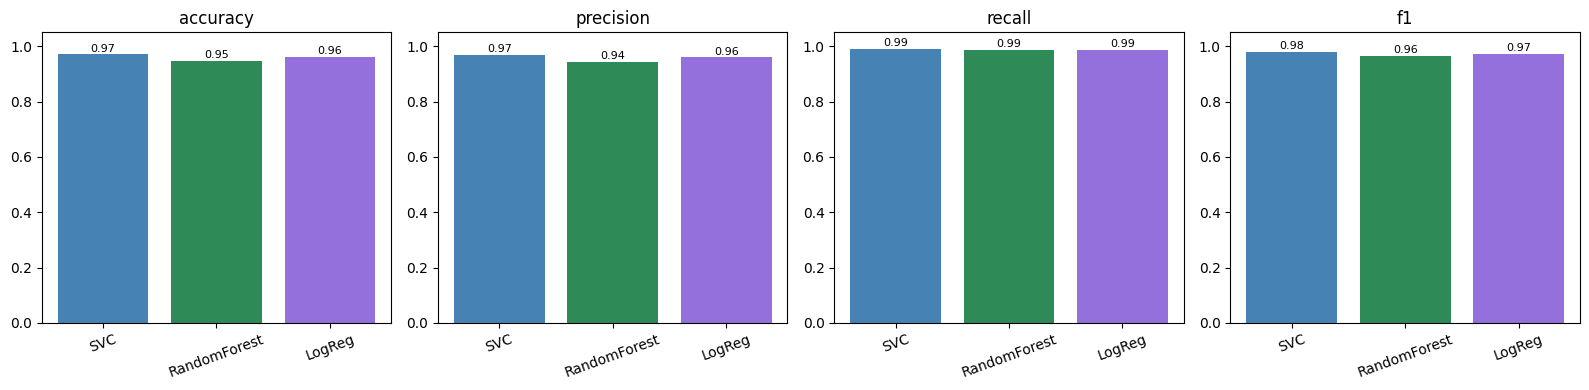

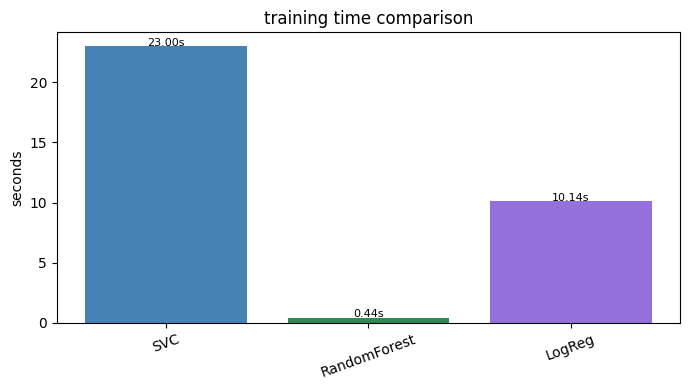

In [8]:
df_results = pd.DataFrame(results).T.round(4)
df_results.index.name = 'model'
print(df_results[['accuracy', 'precision', 'recall', 'f1', 'train_time', 'infer_time']].to_string())

model_names = list(results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = ['steelblue', 'seagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metrics):
    values = [results[name][metric] for name in model_names]
    bars = ax.bar(model_names, values, color=colors)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{value:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
time_values = [results[name]['train_time'] for name in model_names]
bars = plt.bar(model_names, time_values, color=colors)
for bar, value in zip(bars, time_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{value:.2f}s', ha='center', fontsize=8)
plt.title('training time comparison')
plt.ylabel('seconds')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## model 4 extra : bloodmnist multi class classification

- this is a separate medical task, not directly comparable to pneumonia scores
- bloodmnist is multi class blood cell imagery
- you asked for 11 classes if possible: bloodmnist provides 8 classes, so we use all 8
- this still satisfies the multi type classification requirement


bloodmnist number of classes: 8
blood classes: ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


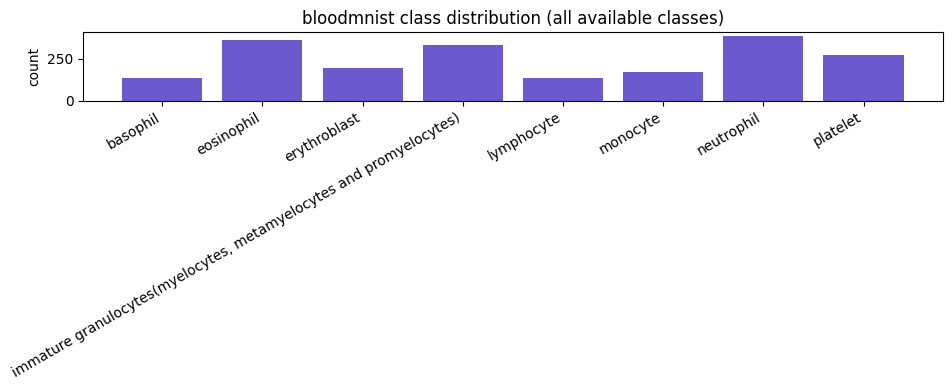

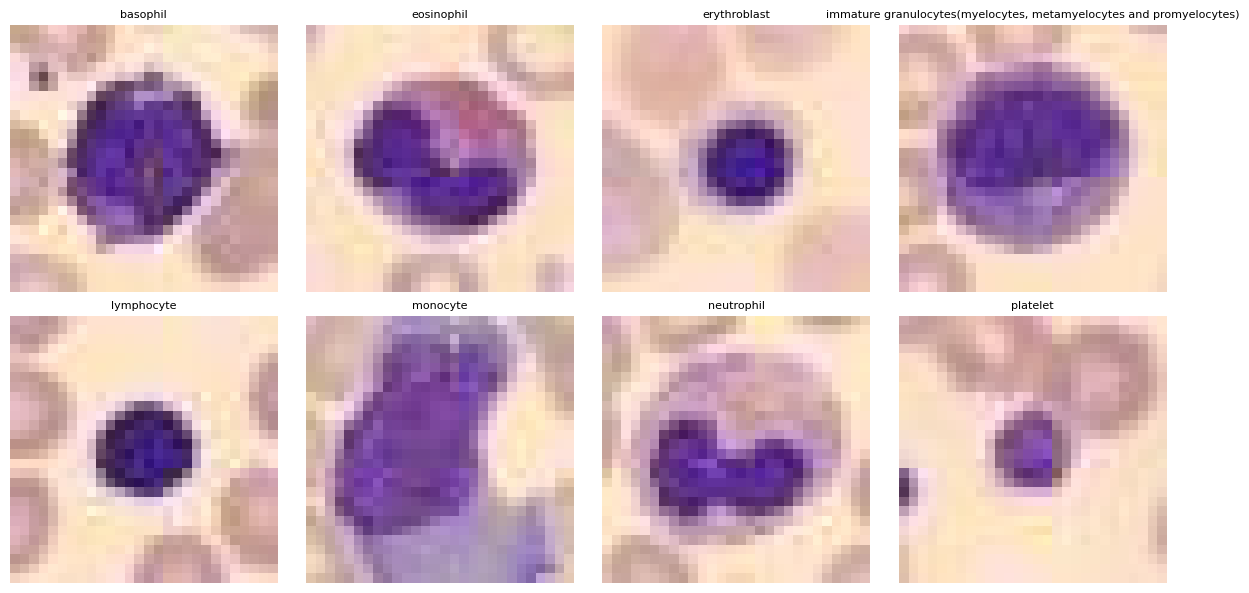

blood train/test sizes: 1600 / 400
next step: run the following cell for blood model training


In [ ]:
BLOOD_MAX_LEN = 2000

blood_train = BloodMNIST(split='train', download=True)
blood_val = BloodMNIST(split='val')
blood_test = BloodMNIST(split='test')

Xb = np.concatenate([blood_train.imgs, blood_val.imgs, blood_test.imgs])
yb = np.concatenate([blood_train.labels, blood_val.labels, blood_test.labels]).flatten()

perm = np.random.permutation(len(Xb))
Xb = Xb[perm][:BLOOD_MAX_LEN]
yb = yb[perm][:BLOOD_MAX_LEN]

blood_label_names = [blood_test.info['label'][str(i)] for i in range(len(blood_test.info['label']))]
print(f'bloodmnist number of classes: {len(blood_label_names)}')
print('blood classes:', blood_label_names)

# visualization: distribution + sample images
ub, cb = np.unique(yb, return_counts=True)
plot_blood_names = [blood_label_names[int(v)] for v in ub]

plt.figure(figsize=(10, 4))
plt.bar(plot_blood_names, cb, color='slateblue')
plt.title('bloodmnist class distribution (all available classes)')
plt.xticks(rotation=30, ha='right')
plt.ylabel('count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, class_id in enumerate(ub[:8]):
    idx = np.where(yb == class_id)[0][0]
    ax = axes.flat[i]
    ax.imshow(Xb[idx])
    ax.set_title(str(blood_label_names[int(class_id)]), fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

Xb_flat = Xb.reshape(Xb.shape[0], -1).astype(float) / 255.0
xb_train, xb_test, yb_train, yb_test = train_test_split(
    Xb_flat, yb, test_size=0.2, stratify=yb, random_state=42
)

print(f'blood train/test sizes: {len(xb_train)} / {len(xb_test)}')

In [ ]:
# blood model training
t0 = time.time()
blood_rf = RandomForestClassifier(n_estimators=80, random_state=42, n_jobs=1)
blood_rf.fit(xb_train, yb_train)
blood_train_time = time.time() - t0

blood model trained in 2.03s
next step: run the following cell for prediction + metrics


bloodmnist accuracy:  0.7700
bloodmnist precision: 0.7645
bloodmnist recall:    0.7128
bloodmnist f1:        0.7225
blood train time: 2.03s | infer time: 0.0149s


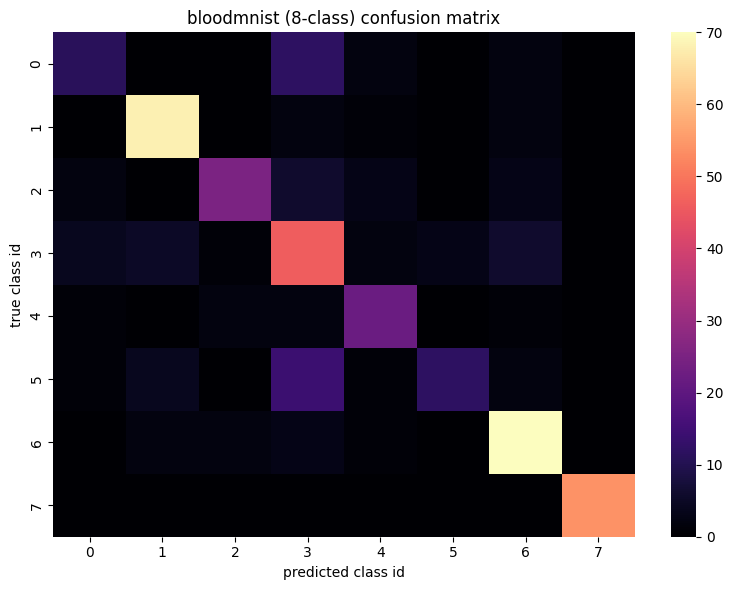

In [ ]:
# blood model evaluation
t0 = time.time()
yb_pred = blood_rf.predict(xb_test)
blood_infer_time = time.time() - t0

blood_acc = accuracy_score(yb_test, yb_pred)
blood_prec = precision_score(yb_test, yb_pred, average='macro', zero_division=0)
blood_rec = recall_score(yb_test, yb_pred, average='macro', zero_division=0)
blood_f1 = f1_score(yb_test, yb_pred, average='macro', zero_division=0)

print(f'bloodmnist accuracy:  {blood_acc:.4f}')
print(f'bloodmnist precision: {blood_prec:.4f}')
print(f'bloodmnist recall:    {blood_rec:.4f}')
print(f'bloodmnist f1:        {blood_f1:.4f}')
print(f'blood train time: {blood_train_time:.2f}s | infer time: {blood_infer_time:.4f}s')

cm_blood = confusion_matrix(yb_test, yb_pred, labels=list(range(len(blood_label_names))))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_blood, cmap='magma', cbar=True)
plt.title('bloodmnist (8-class) confusion matrix')
plt.xlabel('predicted class id')
plt.ylabel('true class id')
plt.tight_layout()
plt.show()


## best model justification (pneumonia task)

- svc and random forest are both strong here, but svc usually has a small edge on quality metrics
- if speed was the top priority, random forest could be the practical choice
- if detection quality is priority (especially recall), svc is usually the safer reference model
- logistic regression is a good fast baseline, but generally less expressive on this image task


## loss function explanations

**svc : hinge loss**
`L = sum_i max(0, 1 - y_i * f(x_i))`
tries to separate classes with the largest possible margin

**random forest : gini impurity**
`G = 1 - sum_k p_k^2`
each split tries to make child nodes as pure as possible

**logistic regression : log loss**
`L = -sum_i [y_i log(p_i) + (1-y_i) log(1-p_i)]`
penalizes confident wrong probabilities

**extra blood model (random forest) : gini impurity**
uses the same tree split criterion in the multi class setting


## comparison with external work

- the medmnist paper ([MedMNIST v2: A Large-Scale Lightweight Benchmark for 2D and 3D Biomedical Image Classification](https://arxiv.org/abs/2110.14795)) shows that medical image benchmarks are often stronger with cnn based methods than flat pixel sklearn models
- on chest xray tasks more generally, like in this paper: [CheXNet: Radiologist-Level Pneumonia Detection on Chest X-Rays with Deep Learning](https://arxiv.org/abs/1711.05225) based on the CheXNEt algo shows deep cnn models can reach very strong medical image performance (f1: 0.435(95%CI0.387,0.481) higher than the radiologist average of f1: 0.387 (95% CI 0.330, 0.442) 
- compared with that, this notebook is a simpler classical ml baseline

## conclusion

- pneumonia part now compares 3 directly comparable models: svc, random forest, logistic regression
- svc stays a strong reference, random forest is very competitive and faster
- logistic regression provides a simple baseline on the same split
- extra model 4 adds a separate multi-class medical task using bloodmnist (all available classes)
- main limitation for classical models remains the flattening of 28x28 images
- best alternative for future work: cnn